In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import nest_asyncio
nest_asyncio.apply()

In [3]:
import os
from pathlib import Path
import uuid
import re
import pandas as pd
from datasets import load_dataset, get_dataset_config_names
from IPython.display import display, Image


In [4]:
import sys, os
sys.path.append(os.path.abspath(".."))  # if needed, adjust to your repo root

In [5]:
DATA_ROOT = Path("../../../dataset/which_vlm_data")
print(DATA_ROOT.resolve())

/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/dataset/which_vlm_data


In [6]:
IMAGES_DIR = DATA_ROOT / "images" / "cauldron"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

### Load the Cauldron Dataset

In [7]:
cauldron_repo = "HuggingFaceM4/the_cauldron"
configs = get_dataset_config_names(cauldron_repo)
len(configs), configs # show first 20

(50,
 ['ai2d',
  'aokvqa',
  'chart2text',
  'chartqa',
  'clevr',
  'clevr_math',
  'cocoqa',
  'datikz',
  'diagram_image_to_text',
  'docvqa',
  'dvqa',
  'figureqa',
  'finqa',
  'geomverse',
  'hateful_memes',
  'hitab',
  'iam',
  'iconqa',
  'infographic_vqa',
  'intergps',
  'localized_narratives',
  'mapqa',
  'mimic_cgd',
  'multihiertt',
  'nlvr2',
  'ocrvqa',
  'okvqa',
  'plotqa',
  'raven',
  'rendered_text',
  'robut_sqa',
  'robut_wikisql',
  'robut_wtq',
  'scienceqa',
  'screen2words',
  'spot_the_diff',
  'st_vqa',
  'tabmwp',
  'tallyqa',
  'tat_qa',
  'textcaps',
  'textvqa',
  'tqa',
  'vistext',
  'visual7w',
  'visualmrc',
  'vqarad',
  'vqav2',
  'vsr',
  'websight'])

In [8]:
target_configs = ["ai2d", "vqav2", "chartqa", "textvqa"]
print(target_configs)
current_config = target_configs[-1]
current_config

['ai2d', 'vqav2', 'chartqa', 'textvqa']


'textvqa'

In [9]:
def load_cauldron_slice(config_name: str, n_samples: int = 32):
    """
    Load the first n_samples from a Cauldron subset.
    """
    ds = load_dataset(
        cauldron_repo,
        config_name,
        # split=f"train[:{n_samples}]",
        streaming=True
    )
    # Load specific subtask in streaming mode for memory efficiency
    # ds = load_dataset("HuggingFaceM4/the_cauldron", "ai2d", split="train[:5]")
    # ds = load_dataset(cauldron_repo, "tallyqa", streaming=True)
    print(f"Loaded {len(ds)} rows from {config_name}")
    print("Columns:", ds.column_names)
    ds = list(ds['train'].take(n_samples))
    return ds

ds_slice = load_cauldron_slice(current_config, n_samples=10)

Loaded 1 rows from textvqa
Columns: {'train': ['images', 'texts']}


In [10]:
print("Rows:", len(ds_slice))
print("Keys:", ds_slice[0].keys())
print("Sample[0] images len:", len(ds_slice[0]["images"]))
print("Sample[0] texts len:", len(ds_slice[0]["texts"]))
print("First text turn:", ds_slice[0]["texts"][0])

Rows: 10
Keys: dict_keys(['images', 'texts'])
Sample[0] images len: 1
Sample[0] texts len: 1
First text turn: {'user': 'What is the brand of phone?\nOffer a terse response.', 'assistant': 'Nokia.', 'source': 'textvqa'}


dict_keys(['images', 'texts']) <class 'list'> <class 'list'>


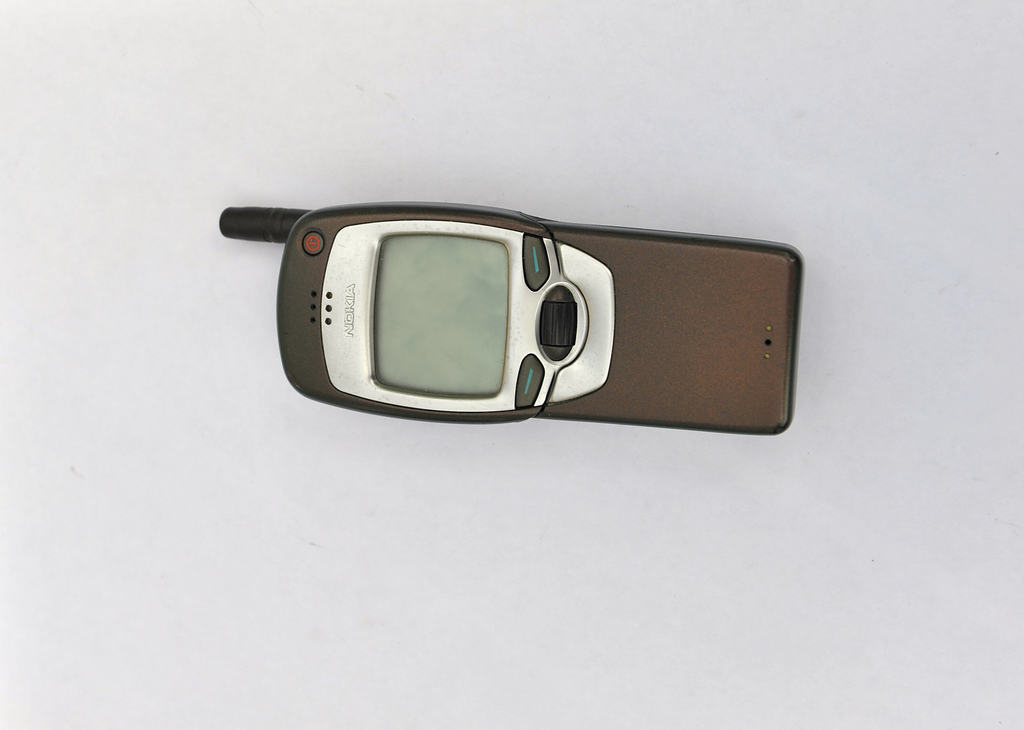

{'user': 'What is the brand of phone?\nOffer a terse response.',
 'assistant': 'Nokia.',
 'source': 'textvqa'}

In [11]:
sample = ds_slice[0]
img = sample["images"][0]
texts = sample["texts"]
print(sample.keys(), type(sample["images"]), type(sample["texts"]))
display(img)
texts[0]

### Test VLM Inference for Sample

In [12]:
from inference_api_call.client import WhichVLMClient

In [13]:

CONFIG_PATH = Path("../configs/inference_vlm.yaml")  # adjust if in a subfolder

client = WhichVLMClient.from_yaml(CONFIG_PATH)

print("All models: ", client.list_models())
print("LLM models:", client.list_llm_models())
print("VLM models:", client.list_vlm_models())

All models:  ['gemma-27b', 'qwen3-8b-thinking', 'qwen-7b', 'qwen-3b', 'deepseek-ocr']
LLM models: []
VLM models: ['gemma-27b', 'qwen3-8b-thinking', 'qwen-7b', 'qwen-3b', 'deepseek-ocr']


In [14]:
vlm_results = client.vlm.run_image(
    image=img,
    text=texts,
    models="all",
)

In [15]:
for name, out in vlm_results.items():
    print("=== VLM:", name, "===")
    if out.get("ok"):
        print(out["response_text"])
        print("Latency (ms):", out["latency_ms"])
    else:
        print("ERROR:", out.get("error"))

=== VLM: qwen3-8b-thinking ===
ERROR: Error code: 400 - {'error': {'message': 'sequence item 0: expected str instance, list found None', 'type': 'BadRequestError', 'param': None, 'code': 400}}
=== VLM: deepseek-ocr ===
ERROR: Error code: 400 - {'error': {'message': 'sequence item 0: expected str instance, list found None', 'type': 'BadRequestError', 'param': None, 'code': 400}}
=== VLM: qwen-3b ===
The brand of the phone in the picture is Nokia.
Latency (ms): 7360
=== VLM: qwen-7b ===
The brand of the phone in the image is Nokia.
Latency (ms): 7373
=== VLM: gemma-27b ===
Here's the answer, based on the image:

Nokia.
Latency (ms): 16195


### Creating Full Dataset

In [16]:
letter_re = re.compile(r"Answer:\s*([A-Z])")

def extract_prompt_and_gt(text_turn):
    user = text_turn["user"]
    assistant = text_turn["assistant"]
    m = letter_re.search(assistant)
    gt_letter = m.group(1) if m else None
    return user, assistant, gt_letter

# quick test
prompt, gt_raw, gt_letter = extract_prompt_and_gt(ds_slice[0]["texts"][0])
prompt[:200], gt_raw, gt_letter


('What is the brand of phone?\nOffer a terse response.', 'Nokia.', None)

In [17]:
def cauldron_to_df(config_name: str, n_samples: int = 64) -> pd.DataFrame:
    ds = load_cauldron_slice(config_name, n_samples=n_samples)
    rows = []

    for i in range(len(ds)):
        sample = ds[i]
        if not sample["images"] or not sample["texts"]:
            continue

        img = sample["images"][0]
        text0 = sample["texts"][0]

        prompt, gt_raw, gt_letter = extract_prompt_and_gt(text0)

        uid = str(uuid.uuid4())
        img_path = IMAGES_DIR / config_name / f"{uid}.png"
        img_path.parent.mkdir(parents=True, exist_ok=True)
        img.save(img_path)

        rows.append(
            dict(
                id=uid,
                source_dataset=f"the_cauldron_{config_name}",
                config=config_name,
                source_index=i,
                image_path=str(img_path),
                prompt=prompt,
                ground_truth_raw=gt_raw,
                ground_truth_letter=gt_letter,
            )
        )

    df = pd.DataFrame(rows)
    return df

cauldron_df_slice = cauldron_to_df(current_config, n_samples=64)
cauldron_df_slice.head()

Loaded 1 rows from textvqa
Columns: {'train': ['images', 'texts']}


,id,source_dataset,config,source_index,image_path,prompt,ground_truth_raw,ground_truth_letter
0,2eaf9cb4-191b-47d1-934e-9a2bcd219db2,the_cauldron_textvqa,textvqa,0,../../../dataset/which_vlm_data/images/cauldro...,What is the brand of phone?\nOffer a terse res...,Nokia.,None
1,e763714f-d67d-4e50-97dc-aefdf44fdb20,the_cauldron_textvqa,textvqa,1,../../../dataset/which_vlm_data/images/cauldro...,What type of plane is this?\nGive a very brief...,Lape.,None
2,2e967078-bc6b-4599-9157-bfa6c64c38f7,the_cauldron_textvqa,textvqa,2,../../../dataset/which_vlm_data/images/cauldro...,Who is this copyrighted by?\nKeep it short and...,Simon clancy.,None
3,0128d3e4-1083-4445-97fe-76d3ea632826,the_cauldron_textvqa,textvqa,3,../../../dataset/which_vlm_data/images/cauldro...,What year is shown in the photo?\nKeep it shor...,2011.,None
4,0e78701d-6d60-450d-8e0a-f800dd865c9c,the_cauldron_textvqa,textvqa,4,../../../dataset/which_vlm_data/images/cauldro...,What is the name of this plane?\nProvide a sho...,G-atco.,None


### Combine all target configs into a single DataFrame

In [18]:

# dfs = []
# for cfg in target_configs:
#     try:
#         df_cfg = cauldron_to_df(cfg, n_samples=64)
#         print(cfg, "->", len(df_cfg), "rows")
#         dfs.append(df_cfg)
#     except Exception as e:
#         print(f"Error loading {cfg}: {e}")

# df_all = pd.concat(dfs, ignore_index=True)
# len(df_all), df_all["source_dataset"].value_counts()


In [19]:
# df_all.sample(frac=1, random_state=42) # frac=1 samples all rows

### Save as paraquet

In [20]:
# out_path = DATA_ROOT / "processed" / "cauldron_poc_multi.parquet"
# out_path.parent.mkdir(parents=True, exist_ok=True)
# df_all.to_parquet(out_path, index=False)
# out_path

In [21]:
# def show_random_example(df: pd.DataFrame, config_name: str):
#     row = df[df["config"] == config_name].sample(1).iloc[0]
#     display(Image(filename=row["image_path"]))
#     print("Config:", row["config"])
#     print("Prompt:\n", row["prompt"])
#     print("GT letter:", row["ground_truth_letter"])
#     print("GT raw:", row["ground_truth_raw"])

# show_random_example(df_all, "ai2d")
# show_random_example(df_all, "chartqa")
